# Has social media influenced Spanish society's opinion on feminism or antifeminism?

In [18]:
# # TO INSTALL
# !pip install -U pip setuptools wheel
# !pip install -U spacy
# !pip install pandas openpyxl

In [ ]:
import pandas as pd
import re
import matplotlib as plt
import plotly.express as px

import seaborn as sns
from scipy.stats import pearsonr

## Influencers initial dataset

In [20]:
path_file_influencers = r"./data/Influencers Initial Dataset.xlsx"

df_influencers = pd.read_excel(path_file_influencers)

df_influencers.head()

,id,influencer's name,real name,age,ref. edad,education,ref. educacion,previous_occupation,ref. ocupacion,main platform,secondary platform,# follower,link_plataforma
0,1,Ibai Llanos,Ibai Llanos Garatea,28,Ibai Llanos - Wikiwand,4,https://www.wikiwand.com/es/Ibai_Llanos,Narrador esports,▷ Ibai Llanos Wiki ≫ Biografía de este Influen...,Twitch,Youtube,"12,8M",ibai - Twitch
1,2,Maria Pombo,María Pombo,28,https://www.modelocurriculum.net/biografias/in...,4,https://www.modelocurriculum.net/biografias/in...,NaN,NaN,Instagram,NaN,"2,9M",https://www.instagram.com/mariapombo/
2,3,Naim Darrechi,Naim Darrechi,20,https://historia-biografia.com/naim-darrechi/,NaN,NaN,-,-,TikTok,Instagram,29M,https://www.tiktok.com/@naimdarrechi?lang=es
3,4,Jordi Wild,Jordi Carrillo de Albornoz Torres,38,▷ Jordi Wild Wiki ≫ Biografía de este Influenc...,6,▷ Jordi Wild Wiki ≫ Biografía de este Influenc...,-,NaN,YouTube,Twitter,"3,59M",The Wild Project - YouTube
4,5,Iker Unzu,Iker Unzueta Ramos,18,"Iker Unzu - Edad, Familia, Biografía | Famous ...",3,Iker Unzu | Wiki YouTube Pedia | Fandom,-,-,TikTok,YouTube,"11,4M",Iker Unzu (@ikerunzu) oficial | TikTok


In [21]:
df_influencers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   26 non-null     int64 
 1   influencer's name    26 non-null     object
 2   real name            26 non-null     object
 3   age                  26 non-null     int64 
 4   ref. edad            25 non-null     object
 5   education            23 non-null     object
 6   ref. educacion       23 non-null     object
 7   previous_occupation  25 non-null     object
 8   ref. ocupacion       24 non-null     object
 9   main platform        26 non-null     object
 10  secondary platform   24 non-null     object
 11  # follower           26 non-null     object
 12  link_plataforma      25 non-null     object
dtypes: int64(2), object(11)
memory usage: 2.8+ KB


In [22]:
df_influencers.shape

(26, 13)

In [70]:
num_rows = df_influencers.shape[0]
num_cols = df_influencers.shape[1]
missing_values = df_influencers.isnull().sum()

summary_text = f"""
Dataset overview:

- Number of rows (influencers): {num_rows}
- Number of columns (features): {num_cols}

"""


summary_text += """

The dataset includes key influencer information such as names, age, education, occupations, platforms, followers, and links. Some columns have missing data.
"""

print(summary_text)



Dataset overview:

- Number of rows (influencers): 26
- Number of columns (features): 5



The dataset includes key influencer information such as names, age, education, occupations, platforms, followers, and links. Some columns have missing data.



In [23]:
df_influencers.isna().sum()  #nan = null

id                     0
influencer's name      0
real name              0
age                    0
ref. edad              1
education              3
ref. educacion         3
previous_occupation    1
ref. ocupacion         2
main platform          0
secondary platform     2
# follower             0
link_plataforma        1
dtype: int64

In [24]:
#remove columns , erase, toke off

df_influencers = df_influencers.drop(['id','real name', 'ref. edad', 'education','ref. educacion', 'previous_occupation', 'ref. ocupacion','link_plataforma'], axis = 1) 

In [25]:
df_influencers.rename(columns={'# follower': 'followers'}, inplace=True) 

In [26]:
df_influencers['followers'].head() #I am going to do a simple process in which I transform objects to numbers using "apply" and "lamda" functions

0    12,8M
1     2,9M
2      29M
3    3,59M
4    11,4M
Name: followers, dtype: object

In [27]:
df_influencers['followers'] = df_influencers['followers'].apply(lambda x: float(x.replace('M', '').replace('K', '').replace(',', '.')) * 1e6)

# df['followers'].str.replace("M","")
# df['followers'].str.replace("K","")
# pd.to_numeric(df['followers']) cuando de error, mirarlo y to_numeric dice qué caracter

In [28]:
df_influencers['followers'].head()  #this is just the "sanity checking"

0    12800000.0
1     2900000.0
2    29000000.0
3     3590000.0
4    11400000.0
Name: followers, dtype: float64

In [29]:
df_influencers['age'].describe() #about numerical data in dataframe

count    26.000000
mean     29.807692
std       6.026735
min      18.000000
25%      26.500000
50%      29.500000
75%      33.000000
max      45.000000
Name: age, dtype: float64

In [30]:
df_influencers.describe(exclude='number') #this frame , this data table

,influencer's name,main platform,secondary platform
count,26,26,24
unique,26,4,6
top,Ibai Llanos,YouTube,Twitter
freq,1,12,8


In [31]:
df_influencers.head()

# I can see the structure of the df_influencers dataset and focus on the aspects I want to analyze
# this leads us to the visual insigths:

,influencer's name,age,main platform,secondary platform,followers
0,Ibai Llanos,28,Twitch,Youtube,12800000.0
1,Maria Pombo,28,Instagram,NaN,2900000.0
2,Naim Darrechi,20,TikTok,Instagram,29000000.0
3,Jordi Wild,38,YouTube,Twitter,3590000.0
4,Iker Unzu,18,TikTok,YouTube,11400000.0


In [ ]:
df_influencers.in

TypeError: 'Index' object is not callable

In [32]:
df_influencers.describe()

,age,followers
count,26.000000,2.600000e+01
mean,29.807692,1.000719e+08
std,6.026735,1.777628e+08
min,18.000000,1.360000e+06
25%,26.500000,2.825000e+06
50%,29.500000,1.035000e+07
75%,33.000000,1.346000e+08
max,45.000000,6.990000e+08


In [50]:
df_influencers = df_influencers.sort_values(by='followers', ascending=False)
df_influencers.head()

,influencer's name,age,main platform,secondary platform,followers
21,Andrea Compton,31,YouTube,Instagram,699000000.0
14,Ines Hernand,30,Instagram,YouTube,468000000.0
20,Victoria Martín,33,Instagram,YouTube,323000000.0
6,Samantha Hudosn,23,Instagram,Twitter,308000000.0
9,Sindy Takanashi,30,Instagram,NaN,264000000.0


In [49]:
df_influencers.iloc[0]

influencer's name     Ibai Llanos
age                            28
main platform              Twitch
secondary platform        Youtube
followers              12800000.0
Name: 0, dtype: object

### Visual Insights

In [44]:
platform_perc_sorted = platform_perc.sort_values('percent')

fig = px.bar(platform_perc_sorted,
             x='percent',
             y='main platform',
             orientation='h',
             text=platform_perc_sorted['percent'].apply(lambda x: f'{x:.1f}%'),
             title="Influencer's Main Platforms",
             labels={'percent': 'Percentage (%)', 'main platform': 'Platform'},
             color_discrete_sequence=['#2A9D8F'])

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis=dict(
        range=[0, 50], 
        showticklabels=False,  
        
        gridwidth=0.5,
        zeroline=False
    ),
    yaxis=dict(title=''),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=14),
    margin=dict(l=100, r=40, t=60, b=40),
)
fig.show()



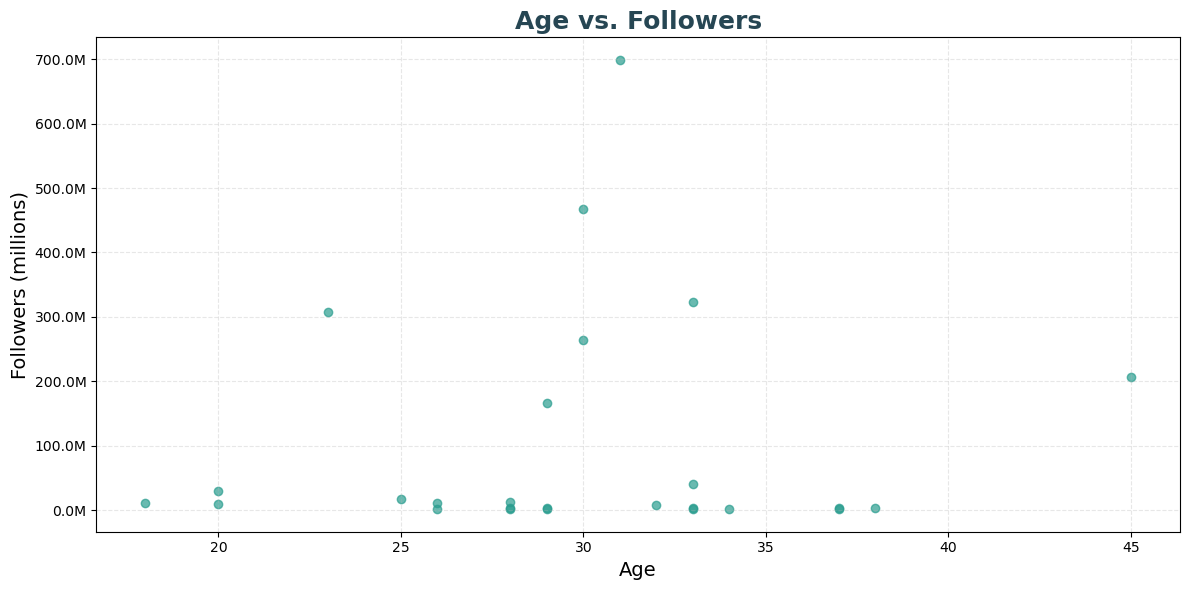

In [ ]:
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'  

plt.figure(figsize=(12, 6))
plt.scatter(df_influencers['age'], df_influencers['followers'], color='#2A9D8F', alpha=0.7)
plt.title('Age vs. Followers', fontsize=18, fontweight='bold', color='#264653')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Followers (millions)', fontsize=14)  # Etiqueta clara

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))
ax.grid(True, linestyle='--', alpha=0.3)  # Grid suave

plt.tight_layout()
plt.show()


In [ ]:
# Age vs Followers interactive

fig = px.scatter(
    df_influencers,
    x='age',
    y='followers',
    color_discrete_sequence=['#2A9D8F'],
    title='Age vs. Followers',
    labels={'age': 'Age', 'followers': 'Followers (millions)'},
    hover_data={'followers': ':.0f', 'age': True}
)

fig.update_layout(
    yaxis=dict(
        tickformat='.1s', 
        title='Followers (millions)',
        gridcolor='lightgrey',
        zeroline=False
    ),
    xaxis=dict(title='Age'),
    plot_bgcolor='white'
)

fig.show()


### 📌 *As we can see in the scatter plot, the points form a sharp “peak” — meaning most influencers aged 25 to 35 have the highest follower counts.*

###  *This curve flattens out at the edges, showing that the youngest and oldest influencers generally have fewer followers, except for a couple of outliers*

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr

correlation, p_value = pearsonr(df_influencers['age'], df_influencers['followers'])
print(f'Correlation between age and number of followers: {correlation:.2f}')

print(f'p-value: {p_value:.3f}') 

#we cannot stablish a relation between these two values.

Correlation between age and number of followers: 0.09
p-value: 0.655


### 📌 The correlation between age and number of followers is close to zero, meaning there’s basically no clear connection between how old an influencer is and how many followers they have. The statistical test confirms this is not a meaningful relationship in our current data.
### To get more confident results or to check if any relationship exists, it’s recommended to analyze a larger dataset with more influencers.